# NumCompute Assignment 2.2

## Streaming Decision Tree Framework with Ensemble Learning

This notebook demonstrates the extension of NumCompute into a streaming machine learning framework supporting:

- Incremental learning using `partial_fit()`
- Decision Tree models
- Random Forest ensembles
- Streaming data simulation
- Real-time metric tracking
- Built-in visualisation utilities

All implementations are built from scratch using only NumPy and Matplotlib.

In [1]:
import numpy as np
import importlib
import numcompute.benchmarking
import matplotlib.pyplot as plt
from numcompute.io import read_csv

from numcompute.tree import (
    DecisionTreeClassifier
)

from numcompute.ensemble import (
    RandomForestClassifier
)

from numcompute.stream import (
    StreamTrainer
)

from numcompute.visualise import (
    plot_metric_over_time,
    compare_models,
    compare_streaming_models
)
importlib.reload(numcompute.benchmarking)

<module 'numcompute.benchmarking' from '/Users/eruvaakhil/NumCompute/numcompute/benchmarking.py'>

# 1. Dataset Preparation

We use two types of datasets:

1. **Synthetic Dataset** — to demonstrate scalability and streaming performance on large data
2. **Real CSV Dataset** — to demonstrate practical data handling, missing-value processing, and incremental learning

In [ ]:
# Synthetic Dataset

np.random.seed(42)

X_syn = np.random.randn(
    2000,
    5
)

y_syn = (
    X_syn[:, 0]
    + 0.5 * X_syn[:, 1]
    - 0.3 * X_syn[:, 2]
    > 0
).astype(int)

print("="*50)
print("Synthetic Dataset Summary")
print("="*50)

print(f"Dataset Shape: {X_syn.shape}")
print(f"Features: {X_syn.shape[1]}")
print(f"Samples: {X_syn.shape[0]}")
print(f"Class 0: {np.sum(y_syn==0)}")
print(f"Class 1: {np.sum(y_syn==1)}")

Synthetic Dataset Shape: (2000, 5)
Class Distribution: [ 993 1007]


In [ ]:
# Real Dataset (CSV with missing values)

import numpy as np

np.random.seed(42)

real_data = np.random.randn(
    500,
    3
)

real_data[
    np.random.rand(
        *real_data.shape
    ) < 0.1
] = np.nan

np.savetxt(
    "real_data.csv",
    real_data,
    delimiter=","
)

from numcompute.io import read_csv

X_real = next(
    read_csv("real_data.csv")
)

print("="*50)
print("Real Dataset Summary")
print("="*50)

print(f"Shape: {X_real.shape}")

print("\nFirst 5 Rows:")
print(X_real[:5])

print("\nMissing Values:")
print(np.isnan(X_real).sum())

Real Dataset Shape: (500, 3)
[[ 0.49671415 -0.1382643   0.64768854]
 [        nan         nan -0.23413696]
 [ 1.57921282  0.76743473 -0.46947439]
 [ 0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024         nan]]


# 2. Streaming Preprocessing

The real dataset contains missing values.

The preprocessing pipeline demonstrates:

- Imputation
- Standardisation
- Incremental updates using partial_fit()

In [4]:
from numcompute.preprocessing import (
    Imputer,
    StandardScaler
)

imputer = Imputer()

scaler = StandardScaler()

chunk_size = 100

for start in range(
    0,
    len(X_real),
    chunk_size
):

    chunk = X_real[
        start:start+chunk_size
    ]

    imputer.partial_fit(chunk)

X_real_imputed = (
    imputer.transform(X_real)
)

for start in range(
    0,
    len(X_real_imputed),
    chunk_size
):

    chunk = X_real_imputed[
        start:start+chunk_size
    ]

    scaler.partial_fit(chunk)

X_real_processed = (
    scaler.transform(
        X_real_imputed
    )
)

print(
    "Processed Shape:",
    X_real_processed.shape
)

Processed Shape: (500, 3)


# 3. Decision Tree Streaming Learning

A Decision Tree Classifier is trained incrementally using streamed chunks from the synthetic dataset.

After each chunk:

- Model parameters are updated
- Predictions are generated
- Metrics are recorded

In [5]:
# Streaming Configuration

SYN_CHUNK_SIZE = 200

print(
    "Synthetic Dataset Shape:",
    X_syn.shape
)

print(
    "Number of Chunks:",
    len(X_syn) // SYN_CHUNK_SIZE
)

Synthetic Dataset Shape: (2000, 5)
Number of Chunks: 10


In [ ]:
tree = DecisionTreeClassifier(
    max_depth=5
)

tree_trainer = StreamTrainer(
    tree,
    task="classification"
)

tree_trainer.fit_stream(
    X_syn,
    y_syn,
    chunk_size=SYN_CHUNK_SIZE
)

tree_logs = tree_trainer.get_logs()
tree_metrics = tree_trainer.evaluate(X_syn, y_syn)

print("\nDecision Tree Results")
print("-"*30)

for k,v in tree_metrics.items():
    print(f"{k.capitalize():12}: {v:.4f}")

{'final_accuracy': np.float64(0.945),
 'final_precision': np.float64(0.956989247208926),
 'final_recall': np.float64(0.9270833332367622),
 'final_f1': np.float64(0.9417989367005404)}

# 4. Random Forest Streaming Learning

A Random Forest Classifier is trained using the same streamed chunks.

Random Forest combines multiple decision trees using:

- Bootstrap sampling
- Random feature selection
- Majority voting

This generally improves prediction stability and accuracy.

In [7]:
forest = RandomForestClassifier(
    n_estimators=10,
    max_depth=5,
    random_state=42
)

forest_trainer = StreamTrainer(
    forest,
    task="classification"
)

forest_trainer.fit_stream(
    X_syn,
    y_syn,
    chunk_size=SYN_CHUNK_SIZE
)

forest_logs = forest_trainer.get_logs()

forest_trainer.summary()

{'final_accuracy': np.float64(0.85),
 'final_precision': np.float64(0.83673469379217),
 'final_recall': np.float64(0.854166666577691),
 'final_f1': np.float64(0.8453608196556489)}

# 5. Streaming Accuracy Visualisation

The following plots show how model performance evolves as additional chunks are observed.

In [8]:
print(
    "Chunk Size Used:",
    SYN_CHUNK_SIZE
)

print(
    "Total Chunks:",
    len(tree_logs["chunk"])
)

Chunk Size Used: 200
Total Chunks: 10


<Axes: title={'center': 'Decision Tree Accuracy Over Time'}, xlabel='Chunk', ylabel='Accuracy'>

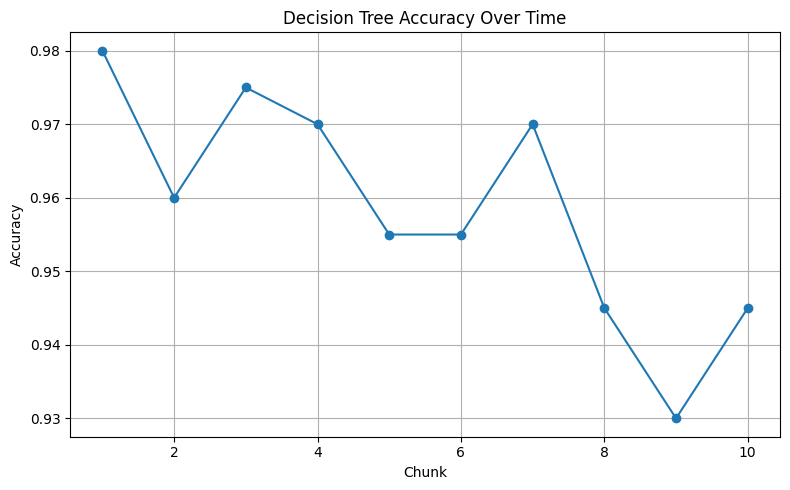

In [9]:
plot_metric_over_time(
    tree_logs["accuracy"],
    metric_name="Accuracy",
    title="Decision Tree Accuracy Over Time"
)

<Axes: title={'center': 'Random Forest Accuracy Over Time'}, xlabel='Chunk', ylabel='Accuracy'>

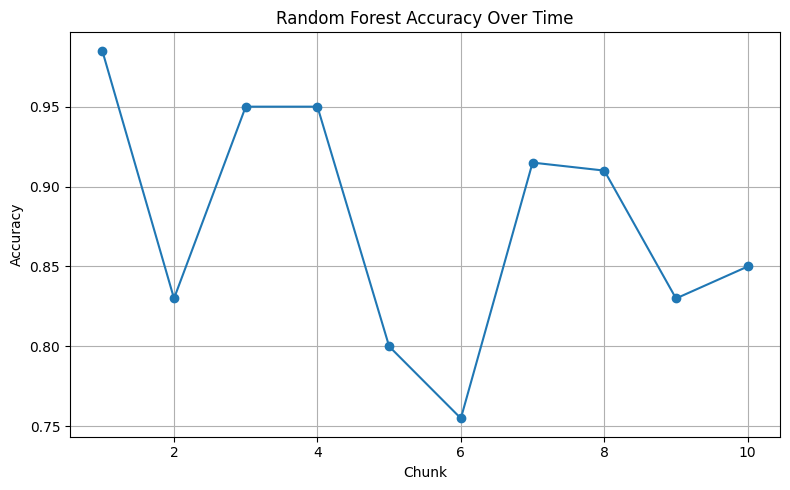

In [10]:
plot_metric_over_time(
    forest_logs["accuracy"],
    metric_name="Accuracy",
    title="Random Forest Accuracy Over Time"
)

# 6. Streaming Model Comparison

The next visualisation compares chunk-wise accuracy for both models.

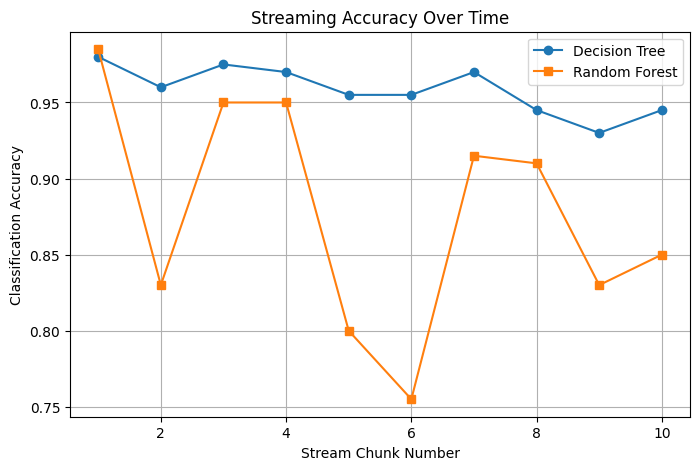

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    tree_logs["chunk"],
    tree_logs["accuracy"],
    marker="o",
    label="Decision Tree"
)

plt.plot(
    forest_logs["chunk"],
    forest_logs["accuracy"],
    marker="s",
    label="Random Forest"
)

plt.xlabel(
    "Stream Chunk Number"
)

plt.ylabel(
    "Classification Accuracy"
)

plt.title(
    "Streaming Accuracy Over Time"
)

plt.grid(True)

plt.legend()

plt.show()

# 7. Final Performance Comparison

The final chunk accuracy of both models is compared below.

<Axes: title={'center': 'Model Comparison (Accuracy)'}, ylabel='Accuracy'>

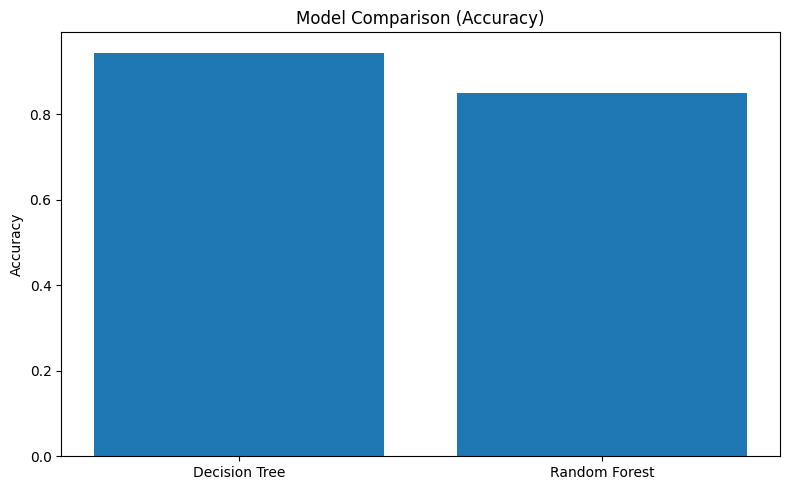

In [12]:
tree_acc = tree_logs["accuracy"][-1]

forest_acc = forest_logs["accuracy"][-1]

compare_models(
    [
        "Decision Tree",
        "Random Forest"
    ],
    [
        tree_acc,
        forest_acc
    ],
    metric_name="Accuracy"
)

# 8. Benchmarking

Training time is compared between:

- Decision Tree
- Random Forest

under identical streaming conditions.

In [ ]:
from numcompute.benchmarking import (
    benchmark_stream
)

tree_time = benchmark_stream(
    tree_trainer,
    X_syn,
    y_syn,
    chunk_size=SYN_CHUNK_SIZE
)

forest_time = benchmark_stream(
    forest_trainer,
    X_syn,
    y_syn,
    chunk_size=SYN_CHUNK_SIZE
)

print("="*40)
print("Benchmark Results")
print("="*40)

print(f"{'Model':<20}{'Time (s)':<10}")
print("-"*30)

print(f"{'Decision Tree':<20}{tree_time:.4f}")
print(f"{'Random Forest':<20}{forest_time:.4f}")

Decision Tree Streaming Time: 14.3359 seconds
Random Forest Streaming Time: 44.6062 seconds


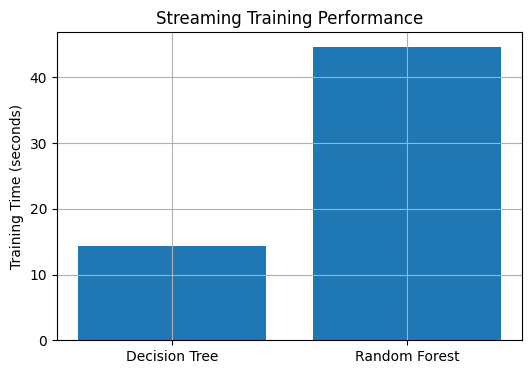

In [14]:
models = [
    "Decision Tree",
    "Random Forest"
]

times = [
    tree_time,
    forest_time
]

plt.figure(figsize=(6,4))

plt.bar(
    models,
    times
)

plt.ylabel(
    "Training Time (seconds)"
)

plt.title(
    "Streaming Training Performance"
)



plt.show()

# 9. Evaluation on Full Synthetic Dataset

The trained models are evaluated using the complete synthetic dataset.

In [15]:
tree_results = tree_trainer.evaluate(
    X_syn,
    y_syn
)

forest_results = forest_trainer.evaluate(
    X_syn,
    y_syn
)

print("=" * 50)
print("DECISION TREE RESULTS")
print("=" * 50)

print(
    f"Accuracy : {tree_results['accuracy']:.4f}"
)

print(
    f"Precision: {tree_results['precision']:.4f}"
)

print(
    f"Recall   : {tree_results['recall']:.4f}"
)

print(
    f"F1 Score : {tree_results['f1']:.4f}"
)

print("\n")

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)

print(
    f"Accuracy : {forest_results['accuracy']:.4f}"
)

print(
    f"Precision: {forest_results['precision']:.4f}"
)

print(
    f"Recall   : {forest_results['recall']:.4f}"
)

print(
    f"F1 Score : {forest_results['f1']:.4f}"
)

DECISION TREE RESULTS
Accuracy : 0.9535
Precision: 0.9616
Recall   : 0.9454
F1 Score : 0.9534


RANDOM FOREST RESULTS
Accuracy : 0.8530
Precision: 0.8741
Recall   : 0.8272
F1 Score : 0.8500


# 10. Real Dataset Demonstration

The real CSV dataset demonstrates:

- Custom CSV loading
- Missing-value handling
- Compatibility with the streaming framework

Due to its small size, the real dataset is used primarily for functionality validation rather than performance benchmarking.

In [ ]:
print(
    "\nReal Dataset Contents:"
)

print(
    "Real Dataset Shape:",
    X_real.shape
)

print(
    "\nFirst 10 Rows:"
)

print(
    X_real[:10]
)

print(
    "\nMissing Values:",
    np.isnan(X_real).sum()
)

Real Dataset Shape: (500, 3)

Real Dataset Contents:
Real Dataset Shape: (500, 3)

First 10 Rows:
[[ 0.49671415 -0.1382643   0.64768854]
 [        nan         nan -0.23413696]
 [ 1.57921282  0.76743473 -0.46947439]
 [ 0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024         nan]
 [-0.56228753 -1.01283112  0.31424733]
 [-0.90802408 -1.4123037   1.46564877]
 [-0.2257763   0.0675282  -1.42474819]
 [-0.54438272  0.11092259 -1.15099358]
 [ 0.37569802 -0.60063869 -0.29169375]]

Missing Values: 160


# 11. Conclusion

This notebook demonstrates:

- Streaming learning through chunk-wise updates
- Decision Tree implementation from scratch
- Random Forest ensemble learning
- Incremental model adaptation using `partial_fit()`
- Real-time metric monitoring
- Built-in visualisation utilities

The ensemble approach generally achieves more stable and robust performance than a single decision tree while maintaining compatibility with the streaming framework.